# Control de calidad y preprocesamiento


## Importaciones

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Obtener dataset consolidado

In [14]:
df_tibaitata = pd.read_pickle("./Datasets/ConsolidadoTibaitata.pkl")
df_tibaitata.info()

<class 'pandas.DataFrame'>
RangeIndex: 36391 entries, 0 to 36390
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CodigoEstacion   36391 non-null  int64         
 1   NombreEstacion   36391 non-null  str           
 2   Variable         36391 non-null  str           
 3   Parametro        36391 non-null  str           
 4   Fecha            36391 non-null  datetime64[us]
 5   Unidad           36391 non-null  str           
 6   Valor            36391 non-null  float64       
 7   NivelAprobacion  36391 non-null  str           
 8   Unidad_esta      36391 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(6)
memory usage: 2.5 MB


## Análisis temporal de disponibilidad

Disponibilidad diaria por parámetro y por año (%)
      Humedad relativa del aire a 2 metros media diaria  \
anio                                                      
2005                                               86.6   
2006                                               82.5   
2007                                               91.8   
2008                                               94.5   
2009                                               77.8   
2010                                               89.0   
2011                                               87.4   
2012                                               59.0   
2013                                               70.1   
2014                                               92.6   
2015                                               94.0   
2016                                               97.5   
2017                                               93.7   
2018                                               95.1   
2019  

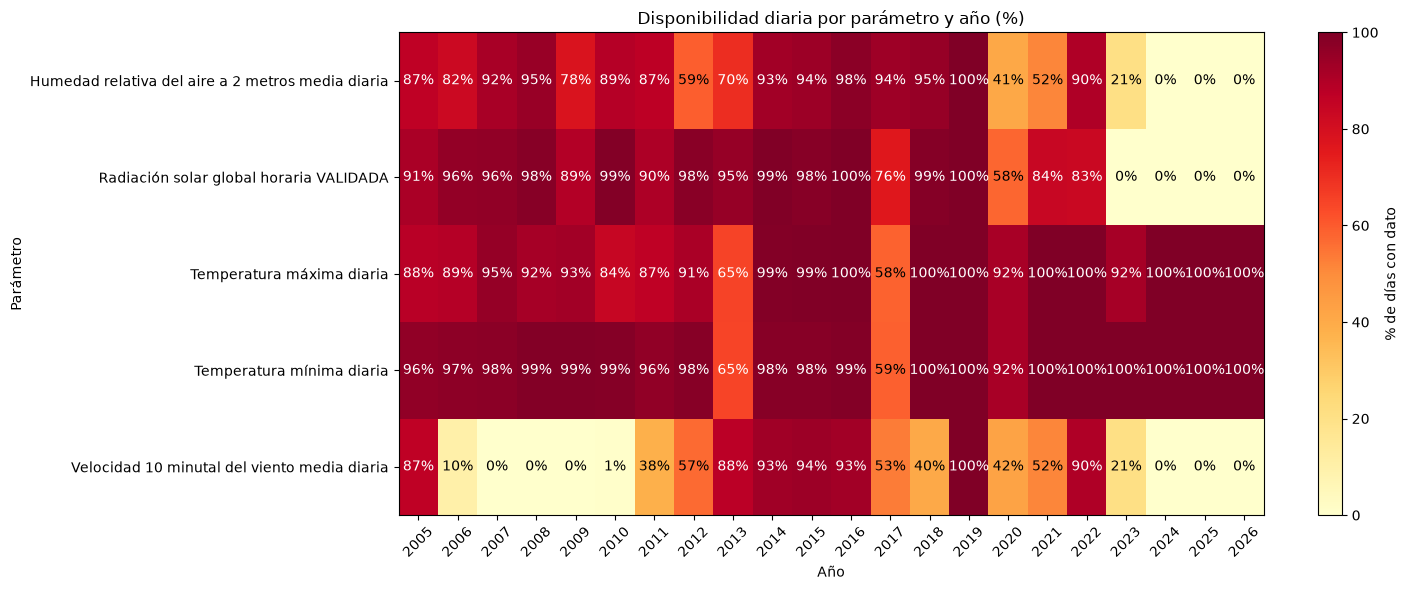

In [15]:
# Medición de disponibilidad diaria por parámetro y por año
# La unidad de análisis sigue siendo el día, pero ahora la agregación se hace por parámetro más específico.
df_disponibilidad = df_tibaitata.copy()
df_disponibilidad['anio'] = df_disponibilidad['Fecha'].dt.year
df_disponibilidad['parametro_limpio'] = df_disponibilidad['Parametro'].fillna(df_disponibilidad['Variable']).astype(str).str.strip()

# Mantener una sola observación por parámetro y por día
dias_con_dato = (
    df_disponibilidad.groupby(['parametro_limpio', 'Fecha'])['Valor'].count().reset_index()
)
dias_con_dato = dias_con_dato.rename(columns={'Valor': 'n_registros'})

# Calendario completo para comparar cada año
fecha_min = df_disponibilidad['Fecha'].min()
fecha_max = df_disponibilidad['Fecha'].max()
calendario = pd.DataFrame({'Fecha': pd.date_range(fecha_min, fecha_max, freq='D')})
calendario['anio'] = calendario['Fecha'].dt.year

param_year = []
for parametro in sorted(df_disponibilidad['parametro_limpio'].dropna().unique()):
    param_dias = dias_con_dato[dias_con_dato['parametro_limpio'] == parametro][['Fecha']].copy()
    param_dias['anio'] = param_dias['Fecha'].dt.year
    dias_disponibles = param_dias.groupby('anio').size()
    dias_totales = calendario.groupby('anio').size()
    pct = (dias_disponibles / dias_totales * 100).fillna(0).rename(parametro)
    param_year.append(pct)

disponibilidad_anio = pd.concat(param_year, axis=1).fillna(0).sort_index()

print('Disponibilidad diaria por parámetro y por año (%)')
print(disponibilidad_anio.round(1))
print('Disponibilidad promedio por parámetro (%)')
print(disponibilidad_anio.mean().round(1).sort_values(ascending=False))

heatmap_df = disponibilidad_anio.copy().T

fig, ax = plt.subplots(figsize=(15, max(6, len(heatmap_df.index) * 0.6)))
im = ax.imshow(heatmap_df.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)


# Visualización resumida: heatmap de disponibilidad por año y parámetro

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=45)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        ax.text(j, i, f'{value:.0f}%', ha='center', va='center', color='black' if value < 60 else 'white')

ax.set_title('Disponibilidad diaria por parámetro y año (%)')
ax.set_xlabel('Año')
ax.set_ylabel('Parámetro')
fig.colorbar(im, ax=ax, label='% de días con dato')
plt.tight_layout()
plt.show()


## Limpieza por duplicados y datos faltantes

### Disponibilidad inicial (antes de limpieza)


Advertencia: no existe df_tibaitata_raw; se usa df_tibaitata actual como referencia ANTES.
Disponibilidad diaria por parámetro y año (ANTES de limpieza, sin años < 15%)
Años descartados por tener al menos un parámetro < 15%: [2006, 2007, 2008, 2009, 2010, 2023, 2024, 2025, 2026]
      Humedad relativa del aire a 2 metros media diaria  \
anio                                                      
2005                                               86.6   
2011                                               87.4   
2012                                               59.0   
2013                                               70.1   
2014                                               92.6   
2015                                               94.0   
2016                                               97.5   
2017                                               93.7   
2018                                               95.1   
2019                                              100.0   
2020        

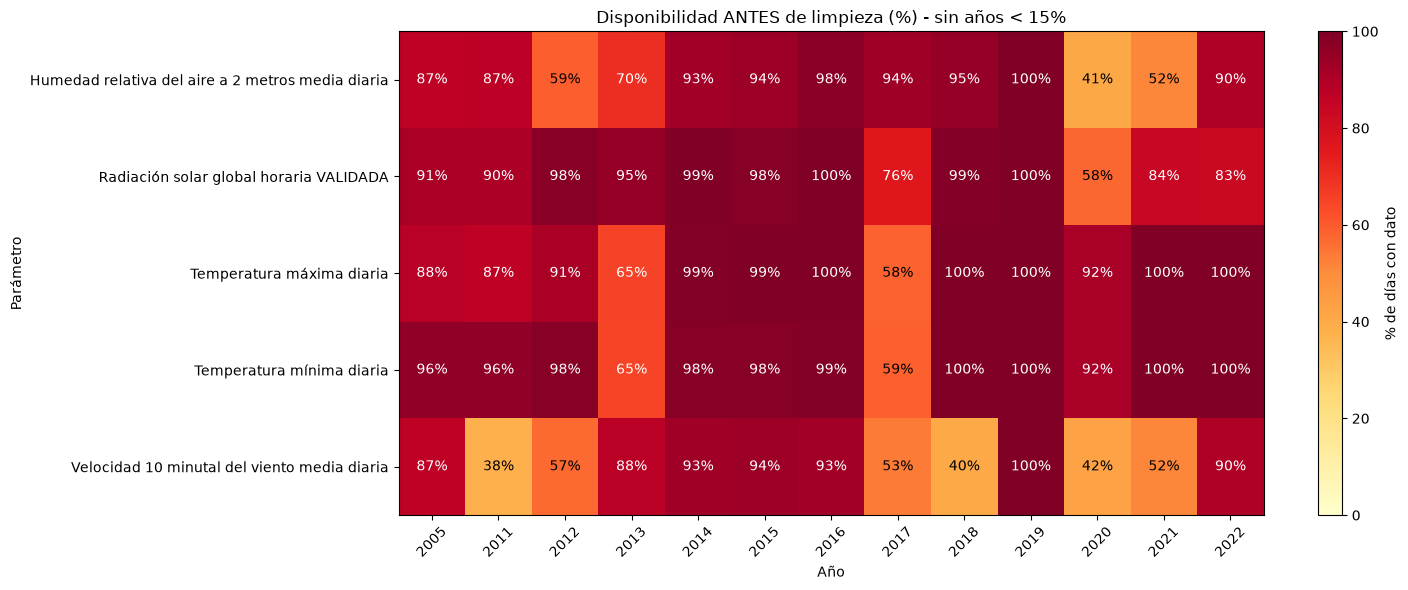

In [16]:
# 1) Heatmap ANTES de la limpieza
if 'df_tibaitata_raw' in globals():
    df_antes_limpieza = df_tibaitata_raw.copy()
else:
    df_antes_limpieza = df_tibaitata.copy()
    print('Advertencia: no existe df_tibaitata_raw; se usa df_tibaitata actual como referencia ANTES.')

df_antes_limpieza['parametro_limpio'] = (
    df_antes_limpieza['Parametro']
    .fillna(df_antes_limpieza['Variable'])
    .astype(str)
    .str.strip()
 )

def calcular_disponibilidad_anual(df_base: pd.DataFrame) -> pd.DataFrame:
    df_disp = df_base.copy()
    df_disp['anio'] = df_disp['Fecha'].dt.year
    df_disp['parametro_limpio'] = (
        df_disp['Parametro']
        .fillna(df_disp['Variable'])
        .astype(str)
        .str.strip()
    )

    dias_con_dato = (
        df_disp.groupby(['parametro_limpio', 'Fecha'])['Valor']
        .count()
        .reset_index()
        .rename(columns={'Valor': 'n_registros'})
    )

    fecha_min = df_disp['Fecha'].min()
    fecha_max = df_disp['Fecha'].max()
    calendario = pd.DataFrame({'Fecha': pd.date_range(fecha_min, fecha_max, freq='D')})
    calendario['anio'] = calendario['Fecha'].dt.year

    param_year = []
    for parametro in sorted(df_disp['parametro_limpio'].dropna().unique()):
        param_dias = dias_con_dato[dias_con_dato['parametro_limpio'] == parametro][['Fecha']].copy()
        param_dias['anio'] = param_dias['Fecha'].dt.year
        dias_disponibles = param_dias.groupby('anio').size()
        dias_totales = calendario.groupby('anio').size()
        pct = (dias_disponibles / dias_totales * 100).fillna(0).rename(parametro)
        param_year.append(pct)

    return pd.concat(param_year, axis=1).fillna(0).sort_index()

def excluir_anios_bajo_umbral(disponibilidad: pd.DataFrame, umbral: float = 15.0) -> pd.DataFrame:
    # Quita años donde al menos un parámetro quede por debajo del umbral (%)
    mask = (disponibilidad >= umbral).all(axis=1)
    return disponibilidad.loc[mask].copy()

def plot_heatmap_disponibilidad(disponibilidad: pd.DataFrame, titulo: str) -> None:
    heatmap_df = disponibilidad.copy().T
    fig, ax = plt.subplots(figsize=(15, max(6, len(heatmap_df.index) * 0.6)))
    im = ax.imshow(heatmap_df.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns, rotation=45)
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)

    for i in range(heatmap_df.shape[0]):
        for j in range(heatmap_df.shape[1]):
            value = heatmap_df.iloc[i, j]
            ax.text(j, i, f'{value:.0f}%', ha='center', va='center', color='black' if value < 60 else 'white')

    ax.set_title(titulo)
    ax.set_xlabel('Año')
    ax.set_ylabel('Parámetro')
    fig.colorbar(im, ax=ax, label='% de días con dato')
    plt.tight_layout()
    plt.show()

umbral_minimo = 15.0
disponibilidad_antes = calcular_disponibilidad_anual(df_antes_limpieza)
disponibilidad_antes_filtrada = excluir_anios_bajo_umbral(disponibilidad_antes, umbral=umbral_minimo)

anios_descartados_antes = sorted(set(disponibilidad_antes.index) - set(disponibilidad_antes_filtrada.index))
print(f'Disponibilidad diaria por parámetro y año (ANTES de limpieza, sin años < {umbral_minimo:.0f}%)')
if anios_descartados_antes:
    print(f'Años descartados por tener al menos un parámetro < {umbral_minimo:.0f}%: {anios_descartados_antes}')
print(disponibilidad_antes_filtrada.round(1))
plot_heatmap_disponibilidad(disponibilidad_antes_filtrada, f'Disponibilidad ANTES de limpieza (%) - sin años < {umbral_minimo:.0f}%')

### Limpieza de duplicados por fecha y parámetro


In [17]:
# 2) Limpieza de duplicados por Fecha + parámetro
df_limpieza = df_antes_limpieza.copy()
df_limpieza['parametro_limpio'] = (
    df_limpieza['Parametro']
    .fillna(df_limpieza['Variable'])
    .astype(str)
    .str.strip()
 )

dup_mask = df_limpieza.duplicated(subset=['Fecha', 'parametro_limpio'], keep=False)
n_filas_duplicadas = int(dup_mask.sum())

# Se consolida duplicado con media en Valor para no perder completamente la señal
cols_clave = ['Fecha', 'parametro_limpio']
cols_texto = ['CodigoEstacion', 'NombreEstacion', 'Variable', 'Parametro', 'Unidad', 'Unidad_esta', 'segmento']

# Validación de consistencia: detectar conflictos de metadatos dentro de la misma clave
cols_revision = [col for col in cols_texto if col in df_limpieza.columns]
if cols_revision:
    conflictos_por_columna = (
        df_limpieza.groupby(cols_clave)[cols_revision]
        .nunique(dropna=False)
        .reset_index()
    )
    conflicto_mask = (conflictos_por_columna[cols_revision] > 1).any(axis=1)
    conflictos = conflictos_por_columna.loc[conflicto_mask].copy()

    if not conflictos.empty:
        print(f'Advertencia: {len(conflictos)} combinaciones Fecha+parámetro tienen metadatos inconsistentes.')
        print('Se conserva el primer valor en columnas de texto para esas combinaciones.')
        print(conflictos.head(5).to_string(index=False))
    else:
        print('Sin conflictos de metadatos en duplicados.')

agg_dict = {'Valor': 'mean'}
for col in cols_texto:
    if col in df_limpieza.columns:
        agg_dict[col] = 'first'

df_sin_duplicados = (
    df_limpieza
    .groupby(cols_clave, as_index=False)
    .agg(agg_dict)
    .sort_values(['Fecha', 'parametro_limpio'])
    .reset_index(drop=True)
 )

print(f'Filas iniciales: {len(df_limpieza)}')
print(f'Filas involucradas en duplicados (Fecha+parámetro): {n_filas_duplicadas}')
print(f'Filas después de quitar duplicados: {len(df_sin_duplicados)}')

Sin conflictos de metadatos en duplicados.
Filas iniciales: 36391
Filas involucradas en duplicados (Fecha+parámetro): 14054
Filas después de quitar duplicados: 29364


### Limpieza de días incompletos

In [18]:
# 3) Limpieza de datos faltantes por día
parametros_esperados = sorted(df_sin_duplicados['parametro_limpio'].dropna().unique())
n_parametros_esperados = len(parametros_esperados)

conteo_param_por_dia = (
    df_sin_duplicados.groupby('Fecha')['parametro_limpio']
    .nunique()
    .rename('n_parametros')
    .reset_index()
 )

fechas_completas = conteo_param_por_dia.loc[
    conteo_param_por_dia['n_parametros'] == n_parametros_esperados, 'Fecha'
].copy()

df_completo = df_sin_duplicados[df_sin_duplicados['Fecha'].isin(fechas_completas)].copy()
df_completo = df_completo.sort_values(['Fecha', 'parametro_limpio']).reset_index(drop=True)

print(f'Parámetros esperados por día: {n_parametros_esperados}')
print(f'Días completos conservados: {df_completo["Fecha"].nunique()} de {df_sin_duplicados["Fecha"].nunique()}')
print(f'Filas finales después de eliminar días incompletos: {len(df_completo)}')

# Este será el DataFrame base para los siguientes análisis
df_tibaitata = df_completo.copy()

Parámetros esperados por día: 5
Días completos conservados: 2909 de 7653
Filas finales después de eliminar días incompletos: 14545


### Disponibilidad final (después de limpieza)

Disponibilidad diaria por parámetro y año (DESPUÉS de limpieza, sin años < 15%)
Años descartados por tener al menos un parámetro < 15%: [2006, 2007, 2008, 2009, 2010]
      Humedad relativa del aire a 2 metros media diaria  \
anio                                                      
2005                                               80.2   
2011                                               32.3   
2012                                               48.1   
2013                                               37.8   
2014                                               90.4   
2015                                               92.1   
2016                                               92.3   
2017                                               24.4   
2018                                               40.3   
2019                                              100.0   
2020                                               33.6   
2021                                               49.0   
2022   

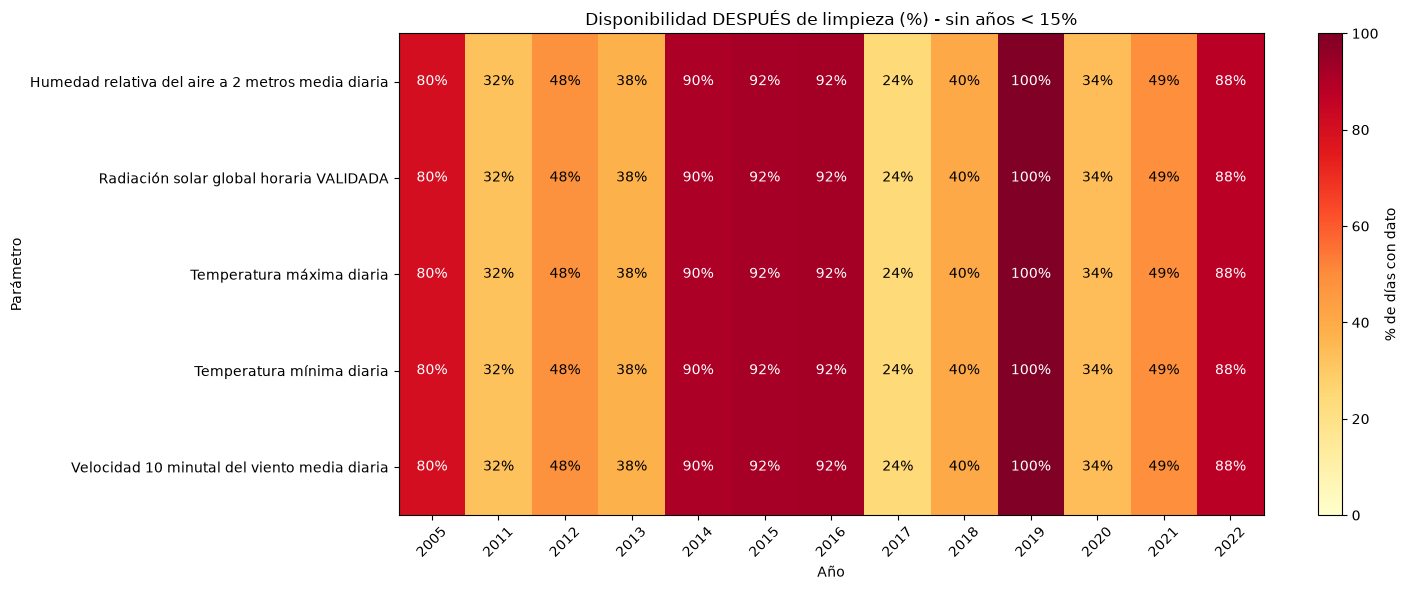

In [19]:
# 4) Heatmap DESPUÉS de la limpieza
umbral_minimo = 15.0
disponibilidad_despues = calcular_disponibilidad_anual(df_tibaitata)
disponibilidad_despues_filtrada = excluir_anios_bajo_umbral(disponibilidad_despues, umbral=umbral_minimo)

anios_descartados_despues = sorted(set(disponibilidad_despues.index) - set(disponibilidad_despues_filtrada.index))
print(f'Disponibilidad diaria por parámetro y año (DESPUÉS de limpieza, sin años < {umbral_minimo:.0f}%)')
if anios_descartados_despues:
    print(f'Años descartados por tener al menos un parámetro < {umbral_minimo:.0f}%: {anios_descartados_despues}')
print(disponibilidad_despues_filtrada.round(1))
plot_heatmap_disponibilidad(disponibilidad_despues_filtrada, f'Disponibilidad DESPUÉS de limpieza (%) - sin años < {umbral_minimo:.0f}%')

## Definir las series temporales disponibles 7, 15, 30 días

In [20]:

df = df_tibaitata.copy()
PARAM_COL = 'Parametro'

# 2. Definir el conjunto de parámetros que se espera tener cada día
#    (todos los que existen en el dataframe)
parametros_esperados = set(df[PARAM_COL].unique())
n_parametros_esperados = len(parametros_esperados)
print(f"Parámetros esperados por día ({n_parametros_esperados}): {sorted(parametros_esperados)}")

# 3. Por cada fecha, ver qué parámetros están presentes (sin duplicados)
cobertura_diaria = (
    df.groupby('Fecha')[PARAM_COL]
    .agg(lambda x: set(x))
    .reset_index(name='parametros_presentes')
)
cobertura_diaria['n_presentes'] = cobertura_diaria['parametros_presentes'].apply(len)
cobertura_diaria['dia_completo'] = cobertura_diaria['n_presentes'] >= n_parametros_esperados

# (opcional) ver qué falta en los días incompletos
cobertura_diaria['faltantes'] = cobertura_diaria['parametros_presentes'].apply(
    lambda s: parametros_esperados - s
)

print(f"Días totales con algún dato: {len(cobertura_diaria)}")
print(f"Días completos (todos los parámetros): {cobertura_diaria['dia_completo'].sum()}")
display(cobertura_diaria)

# 4. Quedarnos solo con los días completos, ordenados
dias_completos = cobertura_diaria.loc[cobertura_diaria['dia_completo'], 'Fecha'].sort_values().reset_index(drop=True)

# 5. Detectar bloques de fechas CONSECUTIVAS (calendario) entre los días completos
diffs = dias_completos.diff()
grupo = (diffs != pd.Timedelta(days=1)).cumsum()

bloques = (
    pd.DataFrame({'Fecha': dias_completos, 'grupo': grupo})
    .groupby('grupo')['Fecha']
    .agg(['min', 'max', 'count'])
    .reset_index(drop=True)
)
bloques.columns = ['fecha_inicio_bloque', 'fecha_fin_bloque', 'dias_disponibles']

print("Bloques de días consecutivos con TODOS los parámetros disponibles:")
display(bloques)

# 6. Generar todas las ventanas posibles (solapadas) de N días dentro de cada bloque
def generar_ventanas(bloques_df, n_dias):
    ventanas = []
    for _, row in bloques_df.iterrows():
        dias_bloque = row['dias_disponibles']
        if dias_bloque >= n_dias:
            inicio_bloque = row['fecha_inicio_bloque']
            n_ventanas = dias_bloque - n_dias + 1
            for i in range(n_ventanas):
                inicio = inicio_bloque + pd.Timedelta(days=i)
                fin = inicio + pd.Timedelta(days=n_dias - 1)
                ventanas.append({'ventana_dias': n_dias, 'fecha_inicio': inicio, 'fecha_fin': fin})
    return pd.DataFrame(ventanas)

ventanas_7 = generar_ventanas(bloques, 7)
ventanas_15 = generar_ventanas(bloques, 15)
ventanas_30 = generar_ventanas(bloques, 30)

resumen_ventanas = pd.concat([ventanas_7, ventanas_15, ventanas_30], ignore_index=True)

print(f"Ventanas de 7 días: {len(ventanas_7)}")
print(f"Ventanas de 15 días: {len(ventanas_15)}")
print(f"Ventanas de 30 días: {len(ventanas_30)}")

display(resumen_ventanas)

Parámetros esperados por día (5): ['Humedad relativa del aire a 2 metros media diaria', 'Radiación solar global horaria VALIDADA', 'Temperatura máxima diaria', 'Temperatura mínima diaria', 'Velocidad 10 minutal del viento media diaria']
Días totales con algún dato: 2909
Días completos (todos los parámetros): 2909


,Fecha,parametros_presentes,n_presentes,dia_completo,faltantes
0,2005-02-02,"{Velocidad 10 minutal del viento media diaria,...",5,True,{}
1,2005-02-03,"{Velocidad 10 minutal del viento media diaria,...",5,True,{}
2,2005-02-04,"{Velocidad 10 minutal del viento media diaria,...",5,True,{}
3,2005-02-05,"{Velocidad 10 minutal del viento media diaria,...",5,True,{}
4,2005-02-06,"{Velocidad 10 minutal del viento media diaria,...",5,True,{}
...,...,...,...,...,...
2904,2022-10-27,"{Velocidad 10 minutal del viento media diaria,...",5,True,{}
2905,2022-10-28,"{Velocidad 10 minutal del viento media diaria,...",5,True,{}
2906,2022-10-29,"{Velocidad 10 minutal del viento media diaria,...",5,True,{}
2907,2022-10-30,"{Velocidad 10 minutal del viento media diaria,...",5,True,{}


Bloques de días consecutivos con TODOS los parámetros disponibles:


,fecha_inicio_bloque,fecha_fin_bloque,dias_disponibles
0,2005-02-02,2005-02-10,9
1,2005-02-12,2005-02-12,1
2,2005-02-14,2005-03-08,23
3,2005-03-11,2005-03-11,1
4,2005-03-13,2005-03-19,7
...,...,...,...
226,2021-08-30,2021-10-31,63
227,2021-11-02,2022-01-02,62
228,2022-02-03,2022-02-15,13
229,2022-02-21,2022-04-21,60


Ventanas de 7 días: 2059
Ventanas de 15 días: 1561
Ventanas de 30 días: 1076


,ventana_dias,fecha_inicio,fecha_fin
0,7,2005-02-02,2005-02-08
1,7,2005-02-03,2005-02-09
2,7,2005-02-04,2005-02-10
3,7,2005-02-14,2005-02-20
4,7,2005-02-15,2005-02-21
...,...,...,...
4691,30,2022-09-28,2022-10-27
4692,30,2022-09-29,2022-10-28
4693,30,2022-09-30,2022-10-29
4694,30,2022-10-01,2022-10-30


## Exportar dataframes

In [22]:
#Dataset de ventanas disponibles
resumen_ventanas.to_pickle("./Datasets/ResumenVentanas.pkl")
#Dataset limpio y procesado
df_tibaitata.to_pickle("./Datasets/TibaitataLimpio.pkl")